In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-


# Deep Neural Networks

## Session 08b
## Introduction to Pytorch
- one hidden layer 
- ${ReLU}$ activation function
- multi-class output
- FIFA dataset 

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
from pathlib import Path
#import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

I0000 00:00:1778207597.572881    6538 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Some basic parameters
inpDir = Path('../../input')
outDir = Path('../output')

RANDOM_STATE = 24
torch.manual_seed(RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 101 # number of epochs
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2
BATCH_SIZE = 32

# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 10),
          'axes.labelsize': 'medium',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.Spectral

plt.rcParams.update(params)

## Helper Function
* Import from util.helper

## Read FIFA 2019 data set
<img src = '../../images/fifa_2019.png' alt = 'Fifa 2019'>

In [4]:
data_df = pd.read_csv(inpDir / 'fifa_2019.csv')
data_df.shape

(18207, 89)

In [5]:
# removing rows with position = null
data_df = data_df[data_df["Position"].notnull()]
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [6]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [7]:
data_df = data_df[rel_cols]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [8]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [9]:
# Create a new column for encoded labels instead of overwriting
data_df['Position_encoded'] = None  # or 0 as placeholder

# Assign labels to goalkeepers
data_df.loc[data_df["Position"] == "GK", "Position_encoded"] = 0

# Defenders
data_df.loc[data_df["Position"].isin(defender), "Position_encoded"] = 1

# Midfielders
data_df.loc[data_df["Position"].isin(midfielder), "Position_encoded"] = 2

# Forward
data_df.loc[data_df["Position"].isin(forward), "Position_encoded"] = 3

# Convert to integer type
data_df['Position_encoded'] = pd.to_numeric(data_df['Position_encoded'], downcast='integer')

In [10]:
class_labels = {0: 'GK', 1: 'Defender', 2: 'Mid Fielder', 3 : 'Forward'}

In [11]:
# Use the new column as your target
y = data_df["Position_encoded"].to_numpy()
X = data_df.drop(columns=["Position", "Position_encoded"])

In [12]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    stratify=y, 
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(14517, 33) (14517,) (3630, 33) (3630,)


In [13]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [14]:
torch.cuda.is_available()

True

In [15]:
torch.version.cuda

'12.8'

In [16]:
torch.cuda.get_device_name(torch.cuda.current_device())

'NVIDIA GeForce RTX 3060 Laptop GPU'

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Define Dataset

In [18]:
class FifaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Convert data to tensors
        self.y = torch.tensor(y, dtype=torch.long)     # Convert labels to tensors

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [19]:
# Create an instance of the dataset
train_dataset = FifaDataset(X_train, y_train)

# Create a DataLoader with batch size of 2 (you can adjust this)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Iterate through the DataLoader
for batch_idx, (data, target) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}: ", end='')
    print("Data:", data.shape, end = ' ')
    print("Target:", target.shape)

Batch 1: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 2: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 3: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 4: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 5: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 6: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 7: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 8: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 9: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 10: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 11: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 12: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 13: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 14: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 15: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 16: Data: torch.Size([32, 33]) Target: torch.Size([32])
Batch 17: Data: t

In [20]:
# Create an instance of the dataset
test_dataset = FifaDataset(X_test, y_test)

# Create a DataLoader with batch size of 2 (you can adjust this)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Iterate through the DataLoader
for batch_idx, (data, target) in enumerate(test_loader):
    print(f"Batch {batch_idx + 1}: ", end='')
    print("Data:", data.shape, end = ' ')
    print("Target:", target.shape)
    break

Batch 1: Data: torch.Size([32, 33]) Target: torch.Size([32])


### Model Definition

Extending nn.Module

In [21]:

class Model ( nn.Module ):
    '''
    Neural network for FIFA player position classification.
    
    Architecture:
    - Input: 33 features (player attributes)
    - Hidden: 18 neurons with SiLU activation
    - Output: 4 classes (GK, Defender, Midfielder, Forward)
    '''
    def __init__ (self, input_dim):
        
        super( Model, self).__init__()
        
        self.layer1 = nn.Linear( input_dim, 18)

        self.activ1 = nn.SiLU()
        
        self.layer2 = nn.Linear( 18, 4)
        
    def forward(self, x):
        
        x = self.layer1 ( x )  # Layer 1 aggregation

        x = self.activ1(x)     # Layer activation

        x =   self.layer2 ( x ) # Layer 2 activations
    
        return x

In [22]:
model = Model(input_dim=X_train.shape[1]).to(device)

In [23]:
list(model.parameters())

[Parameter containing:
 tensor([[-2.4222e-02, -6.6486e-02, -3.5062e-02,  6.3746e-03, -1.4182e-01,
          -4.9749e-02,  1.6879e-01, -3.7317e-02,  1.5855e-01, -6.7960e-02,
          -7.0020e-02, -5.1887e-02, -1.5565e-01, -1.0485e-01,  1.0520e-01,
          -1.3059e-01,  5.9465e-02,  1.6379e-01, -2.2121e-02,  7.6153e-02,
           8.1313e-02, -1.2426e-01, -6.7123e-02, -5.4516e-02,  1.6798e-01,
          -1.5537e-01,  1.0537e-01,  1.6350e-01,  1.3764e-01,  7.4190e-02,
           7.7494e-02, -9.2818e-03,  8.7583e-02],
         [ 1.5868e-01, -5.5976e-02,  1.6820e-01,  2.7665e-02, -1.2210e-01,
          -1.2494e-01,  6.1399e-02, -2.4561e-02, -7.6685e-02,  8.8150e-02,
          -9.1821e-02, -8.3203e-02,  3.2539e-02, -3.1431e-02, -1.4688e-01,
          -5.2295e-02, -6.1178e-02, -7.4187e-02,  1.3552e-01, -2.6404e-02,
          -1.0632e-01,  5.1576e-02,  2.9993e-02, -1.3217e-01, -1.6670e-01,
           1.3171e-01, -1.6122e-01,  1.7279e-01,  9.7198e-02,  1.4528e-01,
          -1.5150e-01,  6.4

In [24]:
# Loss Function
loss_fn = nn.CrossEntropyLoss()

# Optimizers
optimizer = torch.optim.Adam(model.parameters(), lr = ALPHA)

# Some lists to collect data
loss = []
tloss = []
n_epoch = []
acc = []
tacc = []

# Iterations
for epoch in range (EPOCHS):

    model.train() # Set the model in training mode

    epoch_loss = 0
    epoch_acc = 0
    tepoch_loss= 0
    tepoch_acc = 0
    

    for batch_idx, (train_X, train_y) in enumerate(train_loader):

        train_X, train_y = train_X.to(device), train_y.to(device)
    
        predict_prob = model(train_X) # make predictions
    
        batch_loss = loss_fn(predict_prob, train_y) # calculate loss

        epoch_loss += (batch_loss - epoch_loss)/(batch_idx+1) 

        ###---------------
        ### Back prop step
        ###---------------
        optimizer.zero_grad() 
        batch_loss.backward()
        optimizer.step()
        
        _, y_pred = torch.max(predict_prob, 1) # get predicted class from the probabilities
        
        batch_acc = accuracy_score( train_y.cpu().numpy(), y_pred.data.cpu()) # move to CPU

        epoch_acc += (batch_acc - epoch_acc)/(batch_idx+1)

    loss.append ( epoch_loss.data.item() ) # append to loss list
    acc.append(epoch_acc) # append to accuracy list
    
    model.eval() # evaluation mode, prevent from learning

    with torch.inference_mode():
        for batch_idx, (test_X, test_y) in enumerate(test_loader):

            test_X, test_y =test_X.to(device), test_y.to(device)
            
            predict_prob_tst = model(test_X) # make predictions on test data
        
            tbach_loss = loss_fn( predict_prob_tst, test_y)

            tepoch_loss += (tbach_loss - tepoch_loss)/(batch_idx+1)
        
            _, y_pred = torch.max(predict_prob_tst, 1) # get predicted class from the probabilities
        
            tbatch_acc = accuracy_score( test_y.cpu().numpy(), y_pred.data.cpu()) # move to CPU 
            
            tepoch_acc += (tbatch_acc - tepoch_acc) / (batch_idx+1)
        
        tacc.append(tepoch_acc) # append to accuracy list

        tloss.append( tepoch_loss.data.item())  # append to loss list
    
    n_epoch.append(epoch)
    
        
    if epoch % 20 == 0:
        fmtStr = 'Epoch :{:5d}/{:5d} --- Loss: {:.5f}/{:.5f} | Acc {:.5f}/{:.5f}'
        
        print (fmtStr.format(epoch, EPOCHS,
                             epoch_loss.data.item(),
                             tepoch_loss.data.item(),  
                             epoch_acc, 
                             tepoch_acc))

Epoch :    0/  101 --- Loss: 0.55866/0.37192 | Acc 0.79398/0.83748
Epoch :   20/  101 --- Loss: 0.27750/0.29242 | Acc 0.88663/0.87676
Epoch :   40/  101 --- Loss: 0.27027/0.29261 | Acc 0.88783/0.87649
Epoch :   60/  101 --- Loss: 0.26517/0.29638 | Acc 0.88904/0.88040
Epoch :   80/  101 --- Loss: 0.26104/0.29941 | Acc 0.89420/0.87743
Epoch :  100/  101 --- Loss: 0.25860/0.30175 | Acc 0.89358/0.87711


In [25]:
loss_df = pd.DataFrame({'epoch': n_epoch,
                       'loss' : loss,
                       'test_loss' : tloss,
                       'acc' : acc,
                       'test_acc': tacc})

In [26]:
loss_df.head()

,epoch,loss,test_loss,acc,test_acc
0,0,0.558664,0.371923,0.793977,0.837484
1,1,0.338245,0.331302,0.860260,0.856751
2,2,0.315185,0.317137,0.872273,0.863409
3,3,0.304797,0.310101,0.875547,0.863252
4,4,0.298759,0.306123,0.877783,0.865836


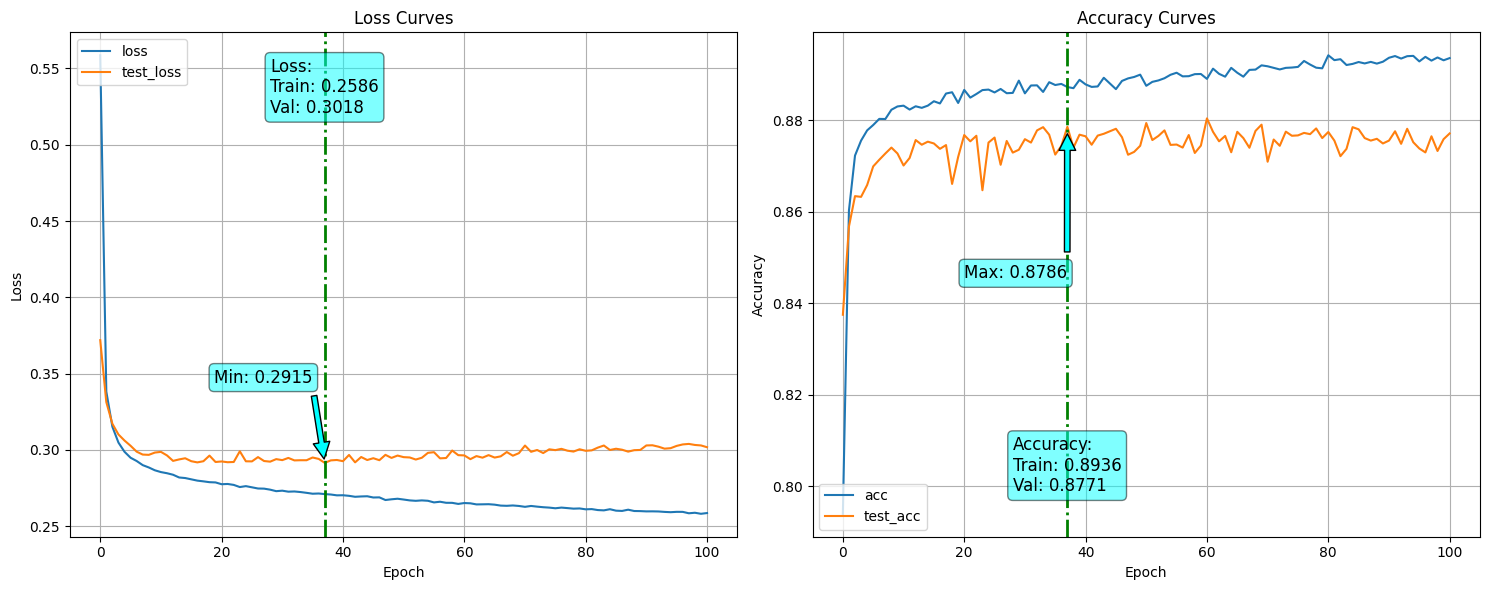

In [27]:
fn_plot_torch_hist(loss_df)

## Performance on Train Data

In [28]:
y_pred = []
y_true = []

model.eval()

with torch.inference_mode():

    for batch_idx, (train_X, train_y) in enumerate(train_loader):

        train_X = train_X.to(device)
        
        outputs = model(train_X)

        y_pred.extend(torch.argmax(outputs, dim = 1).cpu().numpy())

        y_true.extend(train_y)

len(y_pred)

14517

In [29]:
print(classification_report(y_true, y_pred ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1620
           1       0.93      0.94      0.93      4693
           2       0.85      0.87      0.86      5470
           3       0.86      0.80      0.83      2734

    accuracy                           0.90     14517
   macro avg       0.91      0.90      0.91     14517
weighted avg       0.90      0.90      0.89     14517



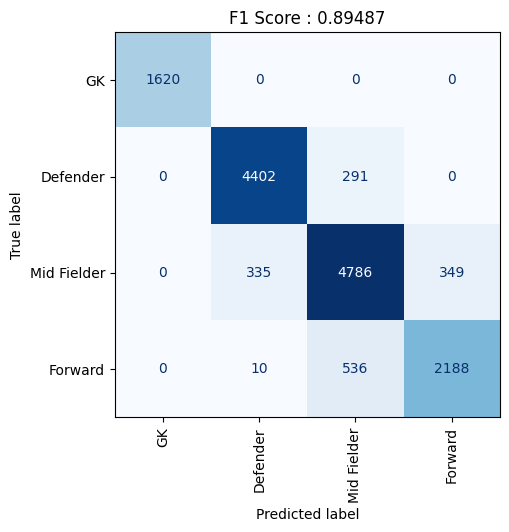

In [30]:
fn_plot_confusion_matrix(y_true, y_pred, labels=class_labels)

## Performance on test data

In [31]:
y_pred = []
y_true = []

model.eval()

with torch.inference_mode():
    for batch_idx, (test_X, test_y) in enumerate(test_loader):

        test_X = test_X.to(device)
        
        outputs = model(test_X)

        y_pred.extend(torch.argmax(outputs, dim = 1).cpu().numpy())

        y_true.extend(test_y)


print(classification_report(y_true, y_pred ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       0.92      0.93      0.92      1173
           2       0.83      0.86      0.84      1368
           3       0.84      0.75      0.79       684

    accuracy                           0.88      3630
   macro avg       0.89      0.88      0.89      3630
weighted avg       0.88      0.88      0.88      3630



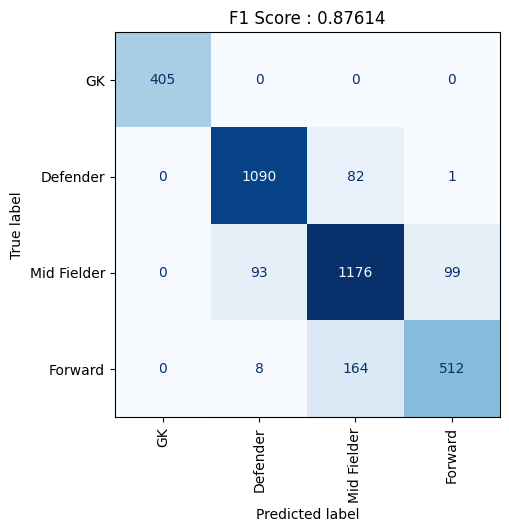

In [32]:
fn_plot_confusion_matrix(y_true, y_pred, labels=class_labels)